In [28]:
import sqlite3
import pandas as pd
import io


conn = sqlite3.connect(':memory:')
cursor = conn.cursor()


cursor.execute("""
CREATE TABLE raw_customer_data (
    customerID VARCHAR(20) PRIMARY KEY,
    gender VARCHAR(10),
    SeniorCitizen INT,
    Partner VARCHAR(3),
    Dependents VARCHAR(3),
    tenure INT,
    PhoneService VARCHAR(3),
    MultipleLines VARCHAR(50),
    InternetService VARCHAR(50),
    OnlineSecurity VARCHAR(50),
    OnlineBackup VARCHAR(50),
    DeviceProtection VARCHAR(50),
    TechSupport VARCHAR(50),
    StreamingTV VARCHAR(50),
    StreamingMovies VARCHAR(50),
    Contract VARCHAR(50),
    PaperlessBilling VARCHAR(3),
    PaymentMethod VARCHAR(50),
    MonthlyCharges DECIMAL(10, 2),
    TotalCharges VARCHAR(20),
    Churn VARCHAR(3)
);
""")


df_raw = pd.read_csv('/content/sample_data/Telco-Customer-Churn.csv')
df_raw.to_sql('raw_customer_data', conn, if_exists='append', index=False)


cursor.execute("""
CREATE VIEW tableview AS
SELECT
    SeniorCitizen,
    tenure,
    MonthlyCharges,
    CAST(NULLIF(TotalCharges, '') AS DECIMAL(10,2)) AS TotalCharges,
    CASE WHEN gender = 'Male' THEN 1
        ELSE 0
        END AS gender_encoded,

    CASE WHEN Contract = 'Month-to-month' THEN 0
         WHEN Contract = 'One year' THEN 1
         ELSE 2
         END AS contract_encoded,

    CASE WHEN Churn = 'Yes' THEN 1
         ELSE 0
         END AS Churn
FROM raw_customer_data;
""")


df_ml = pd.read_sql("SELECT * FROM tableview", conn)
print(" Data successfully cleaned ")
print(df_ml.head())

 Data successfully cleaned 
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_encoded  \
0              0       1           29.85         29.85               0   
1              0      34           56.95       1889.50               1   
2              0       2           53.85        108.15               1   
3              0      45           42.30       1840.75               1   
4              0       2           70.70        151.65               0   

   contract_encoded  Churn  
0                 0      0  
1                 1      0  
2                 0      1  
3                 1      0  
4                 0      1  


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_ml[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df_ml[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.66      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



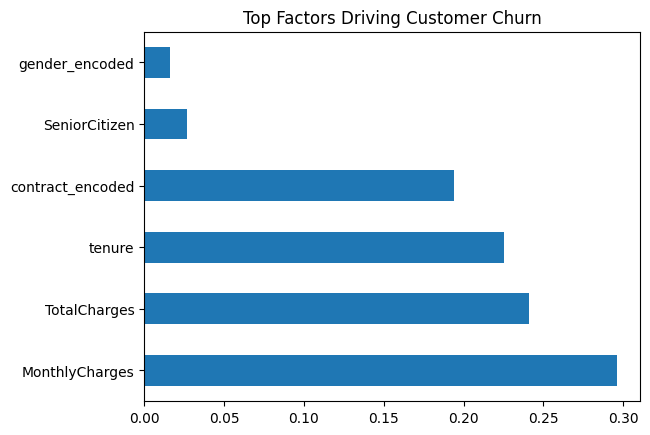

In [37]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Factors Driving Customer Churn")
plt.show()

 Overall Accuracy: 80.13%

 Detailed Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.66      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



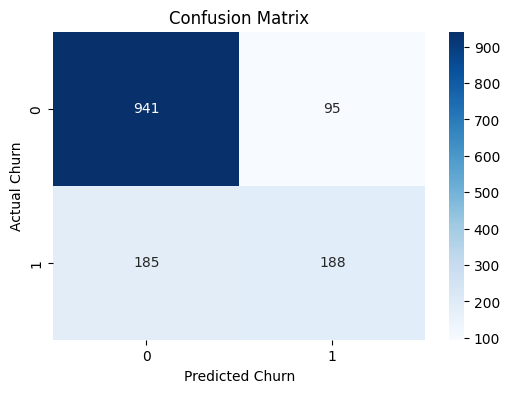


 ROC-AUC Score: 0.8464


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(f" Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n Detailed Report")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('Actual Churn')
plt.xlabel('Predicted Churn')
plt.show()

probs = model.predict_proba(X_test)[:, 1]
print(f"\n ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")